#Pipeline for Enviromental Audio Classification using Custom CNN Pipeline

In [ ]:
# Import Neccesary Libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio.transforms as spec
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import Dataset
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

# Check and set device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
if device.type == "cuda":
    print(f"GPU             : {torch.cuda.get_device_name(0)}")


PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4


In [ ]:
# Import dataset from HuggingFace
from datasets import load_dataset
audio_dataset = load_dataset("ashraq/esc50")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/345 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00002-2f1ab7b824ec75(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

data/train-00001-of-00002-27425e5c1846b4(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# Split dataset into training / validation / testing datasets
# Calculate index splits based on 70 / 15 / 15 ssample splits
total_samples = int(len(audio_dataset["train"]))
train_end = int(0.70 * total_samples)
val_end   = int(0.85 * total_samples)

# Split the datasets accordingly
total_set = audio_dataset["train"].shuffle(seed=42)
training_dataset = total_set.select(range(train_end))
validation_dataset   = total_set.select(range(train_end, val_end))
testing_dataset  = total_set.select(range(val_end, total_samples))

# Verify size of split datasets
print("No. of Training Samples: " + str(len(training_dataset)))
print("No. of Validation Samples: " + str(len(validation_dataset)))
print("No. of Testing Samples: " + str(len(testing_dataset)))

No. of Training Samples: 1400
No. of Validation Samples: 300
No. of Testing Samples: 300


In [ ]:
# Example metadata extraction
print(total_set)
print("\n")
def metadata_extraction(sample):
  print("Filename: " + sample["filename"])
  print("K-Fold F: " + str(sample["fold"]))
  print("Target Class (y_hat): " + str(sample["target"]))
  print("Class (in english): " + sample["category"])
  print("metadata: " + str(sample["src_file"]))
  print("metadata: " + str(sample["take"]))
  print("Audio Features: ")
  print(sample["audio"]["array"])

metadata_extraction(training_dataset[0])

Dataset({
    features: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take', 'audio'],
    num_rows: 2000
})


Filename: 5-160614-A-48.wav
K-Fold F: 5
Target Class (y_hat): 48
Class (in english): fireworks
metadata: 160614
metadata: A
Audio Features: 
[-0.01043701 -0.01016235 -0.00976562 ...  0.01290894  0.01477051
  0.01657104]


/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


torch.Size([1, 128, 431])


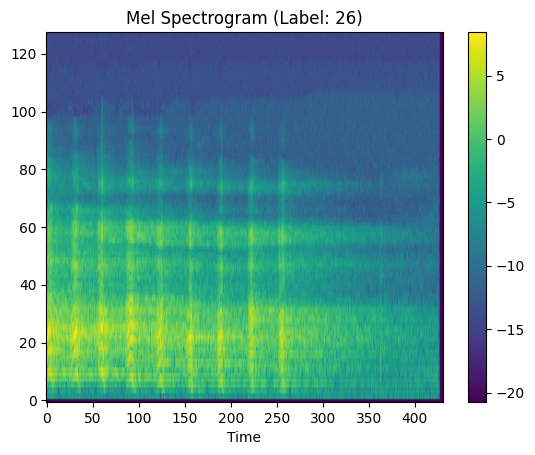

In [ ]:
# Create PyTorch Datasets
class ESC50TorchDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset):
        self.ds = hf_dataset
        self.mel_spec = spec.MelSpectrogram( # convert to spectrogram (parameters are subject to change)
            sample_rate=44100,
            n_fft=1024,
            hop_length=512,
            n_mels=128
        )

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        waveform = torch.tensor(sample["audio"]["array"], dtype=torch.float32) # torch tensor conversion
        if waveform.ndim == 1:
            waveform = waveform.unsqueeze(0)
        mel_spec = self.mel_spec(waveform) # convert to spectrogram
        mel_spec = torch.log(mel_spec + 1e-9)
        target = torch.tensor(sample["target"], dtype=torch.long)

        return mel_spec, target

train_torch_dataset = ESC50TorchDataset(training_dataset)
val_torch_dataset = ESC50TorchDataset(validation_dataset)
test_torch_dataset = ESC50TorchDataset(testing_dataset)

# Tesinting  how the the spectrogram images turned out
x, y = train_torch_dataset[132]
#print(x)
#print(x.shape)
#print(y)

mel_spec = x[-1].numpy()
print(x.shape)


plt.figure()
plt.imshow(mel_spec, aspect='auto', origin='lower')
plt.title(f"Mel Spectrogram (Label: {y})")
plt.xlabel("Time")
plt.colorbar()
plt.show()

In [ ]:
# Dataloader(s)
training_loader = DataLoader(
    dataset=train_torch_dataset,
    batch_size=64,
    shuffle=True
)

validation_loader = DataLoader(
    dataset=val_torch_dataset,
    batch_size=64,
    shuffle=True #maybe change idk if validation is shuffled or not
)

test_loader = DataLoader(
    dataset=test_torch_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        # Input after padding: 1 x 448 x 128
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)   # 448x128 -> 224x64

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)  # 224x64 -> 112x32

        self.conv5 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.conv6 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1) # 112x32 -> 56x16

        self.conv7 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.conv8 = nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1) # 56x16 -> 28x8

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = F.pad(x, (8,9,0,0), mode='replicate') # Add padding so spectr. is div by power of 2
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))

        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))

        x = F.relu(self.conv7(x))
        x = F.relu(self.conv8(x))

        x = self.global_pool(x)          # N x 256 x 1 x 1
        x = torch.flatten(x, 1)          # N x 256

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [ ]:
# Hyperparameters
learning_rate = 0.0001
epochs = 500
num_classes = 50

model = CNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)





In [ ]:
# Training Loop
for epoch in range(epochs):
    # ===== TRAINING =====
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, targets) in enumerate(training_loader):
        data = data.to(device)
        targets = targets.to(device)

        # Forward pass
        outputs = model(data)
        loss = criterion(outputs, targets)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == targets).sum().item()
        total += targets.size(0)

    train_loss = running_loss / len(training_loader)
    train_acc = 100 * correct / total

    # ===== VALIDATION =====
    model.eval()

    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for data, targets in validation_loader:
            data = data.to(device)
            targets = targets.to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == targets).sum().item()
            val_total += targets.size(0)

    val_loss /= len(validation_loader)
    val_acc = 100 * val_correct / val_total

    # ===== PRINT =====
    print(
        f'Epoch [{epoch+1}/{epochs}] | '
        f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
        f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%'
    )


Epoch [1/500] | Train Loss: 3.9126 | Train Acc: 2.29% | Val Loss: 3.9119 | Val Acc: 2.00%
Epoch [2/500] | Train Loss: 3.8942 | Train Acc: 2.14% | Val Loss: 3.8859 | Val Acc: 2.00%
Epoch [3/500] | Train Loss: 3.8619 | Train Acc: 1.93% | Val Loss: 3.7983 | Val Acc: 4.00%
Epoch [4/500] | Train Loss: 3.8034 | Train Acc: 4.07% | Val Loss: 3.7532 | Val Acc: 3.67%
Epoch [5/500] | Train Loss: 3.7423 | Train Acc: 4.14% | Val Loss: 3.7418 | Val Acc: 3.67%
Epoch [6/500] | Train Loss: 3.7342 | Train Acc: 4.21% | Val Loss: 3.6924 | Val Acc: 3.00%
Epoch [7/500] | Train Loss: 3.6951 | Train Acc: 4.29% | Val Loss: 3.6719 | Val Acc: 3.67%
Epoch [8/500] | Train Loss: 3.6915 | Train Acc: 3.79% | Val Loss: 3.6787 | Val Acc: 3.67%
Epoch [9/500] | Train Loss: 3.6627 | Train Acc: 5.00% | Val Loss: 3.6119 | Val Acc: 5.33%
Epoch [10/500] | Train Loss: 3.6437 | Train Acc: 4.29% | Val Loss: 3.5918 | Val Acc: 5.67%
Epoch [11/500] | Train Loss: 3.6293 | Train Acc: 5.21% | Val Loss: 3.5657 | Val Acc: 4.33%
Epoch [1